<a href="https://colab.research.google.com/github/sandeshdesai07/CNN_Cat_Dog_Classification/blob/main/CNN_Cat_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/


cp: cannot stat 'kaggle.json': No such file or directory


In [54]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
dogsvscats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [55]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [56]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential, regularizers
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten, BatchNormalization, Dropout

In [57]:
#Generators we are taking as batch of 32 picturs for training instead of each image

train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',  #it will automatically assign number based on folder
    label_mode = 'int',   #it will asigned integer values to the folders
    batch_size = 32,      #it takes this number as total number froma ll of the number of images
    image_size = (256, 256) #it will crop the image in 256 * 256 ratio
)


validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',  #it will automatically assign number based on folder
    label_mode = 'int',   #it will asigned integer values to the folders
    batch_size = 32,      #it takes this number as total number froma ll of the number of images
    image_size = (256, 256) #it will crop the image in 256 * 256 ratio
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [58]:
# Normalize
def process(image, label):
  image = tf.cast(image/255. , tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [128]:

model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3,3), padding="valid", activation="relu",kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001), input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"))

model.add(Conv2D(filters=32, kernel_size=(3,3), padding="valid", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding="valid"))

model.add(Conv2D(filters=32, kernel_size=(3,3), padding="valid", activation="relu"))


model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [129]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 125, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,773,697 (56.36 MB)

 Trainable params: 14,773,569 (56.36 MB)

 Non-trainable params: 128 (512.00 B)

In [130]:
model.compile(optimizer=keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

In [83]:
model.compile(optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

In [131]:
history = model.fit(train_ds, epochs=5, validation_data=validation_ds)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 79ms/step - accuracy: 0.6564 - loss: 0.6772 - val_accuracy: 0.6816 - val_loss: 0.6509
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.7514 - loss: 0.5698 - val_accuracy: 0.7434 - val_loss: 0.5808
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.7994 - loss: 0.4972 - val_accuracy: 0.7414 - val_loss: 0.5898
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.8377 - loss: 0.4323 - val_accuracy: 0.7570 - val_loss: 0.5715
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.8742 - loss: 0.3701 - val_accuracy: 0.7764 - val_loss: 0.5415


In [141]:
model.save("cat-vs-dogs-trained-modell.h5")
model.save("cat-vs-dogs-trained-modell.keras")

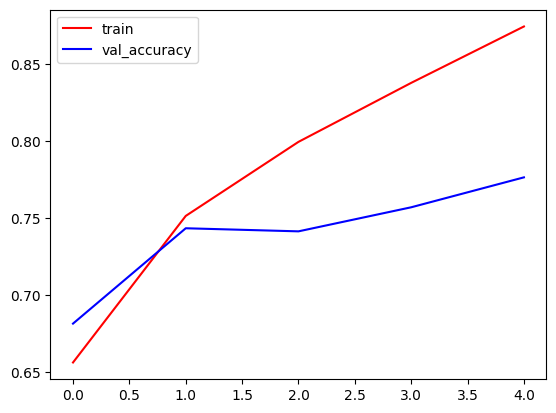

In [133]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='val_accuracy')
plt.legend()
plt.show()

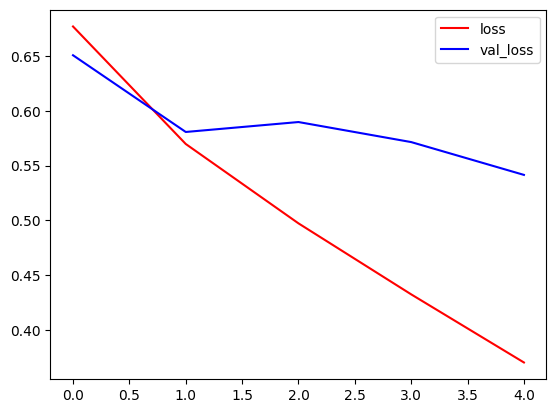

In [134]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='loss')
plt.plot(history.history['val_loss'],color='blue',label='val_loss')
plt.legend()
plt.show()

In [143]:
import cv2

In [144]:
dog = cv2.imread('/Weights-Cat-vs-Dogs-CNN-Project/dog.jpg')
blurrdog = cv2.imread('/Weights-Cat-vs-Dogs-CNN-Project/blurrdog.jpg')
blurrcat = cv2.imread('/Weights-Cat-vs-Dogs-CNN-Project/blurrcat.jpeg')

In [145]:
print (cat.shape,
blurrcat.shape,
blurrdog.shape)

(256, 256, 3) (911, 700, 3) (585, 780, 3)


In [146]:
blurrcat = cv2.resize(blurrcat,(256,256))
cat = cv2.resize(cat,(256,256))
blurrdog = cv2.resize(blurrdog,(256,256))

In [147]:
blurrcatip = blurrcat.reshape((1,256,256,3))
catip = cat.reshape((1,256,256,3))
blurrdogip = blurrdog.reshape((1,256,256,3))


In [148]:
print(
    model.predict(blurrcatip),
    model.predict(catip),
    model.predict(blurrdogip)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.]] [[0.]] [[1.]]
